# EDA: Bhutan Major Basin Discharge Data

**What you'll get:**
- Clean loading of each sheet (station) while skipping metadata rows
- Per‑station summary stats in tables
- Inline time‑series plots, histograms, and average monthly flow per station
- A combined monthly average plot across stations

## 1) Parameters

In [1]:
# --- User parameters ---
INPUT_XLSX = "../../data/Discharge data Major Basin.xlsx" 
SKIPROWS = 3                                               # metadata rows before header row (header at row 4)
print("Input:", INPUT_XLSX)


Input: ../../data/Discharge data Major Basin.xlsx


## 2) Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## 3) Inspect workbook sheets

In [3]:
xls = pd.ExcelFile(INPUT_XLSX)
sheets = xls.sheet_names
sheets

['Lungtenphu (Wangchhu)',
 'Wangdi rapid (Punatshangchhu)',
 'Pangbang dangmechhu',
 'tingtibi (Mangdichhu)',
 'Kurjey (Chamkharchhu)']

## 4) Helper function to load and clean a station sheet

In [4]:
def load_station_sheet(xlsx_path: str, sheet_name: str, skiprows: int = 3):
    """
    Load one sheet (station) and do minimal cleaning:
      - Skip metadata rows (default: 3)
      - Trim column names; harmonize 'water Level' -> 'Water Level' if present
      - Parse 'Date' to datetime
      - Coerce 'Flow' and 'Water Level' to numeric
      - Drop entirely-empty columns
      - Sort by 'Date'
    """
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name, skiprows=skiprows)
    df = df.dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    if "water Level" in df.columns and "Water Level" not in df.columns:
        df = df.rename(columns={"water Level": "Water Level"})
    if "Date" not in df.columns:
        raise ValueError(f"'Date' column not found in sheet: {sheet_name}")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Flow", "Water Level"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    keep = [c for c in ["Date", "Flow", "Water Level"] if c in df.columns]
    df = df[keep].dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    return df


## 5) Utility: compute per‑station summary statistics

In [5]:
def station_summary(df: pd.DataFrame) -> dict:
    out = {}
    out["Start Date"] = df["Date"].min().date() if len(df) else None
    out["End Date"] = df["Date"].max().date() if len(df) else None
    out["N Obs"] = int(len(df))
    if "Flow" in df.columns:
        flow = df["Flow"]
        out["Mean Flow"] = float(flow.mean())
        out["Median Flow"] = float(flow.median())
        out["Min Flow"] = float(flow.min())
        out["Max Flow"] = float(flow.max())
        out["Std Flow"] = float(flow.std())
        out["Missing Flow"] = int(flow.isna().sum())
    else:
        out["Mean Flow"] = out["Median Flow"] = out["Min Flow"] = out["Max Flow"] = out["Std Flow"] = None
        out["Missing Flow"] = None
    if "Water Level" in df.columns:
        wl = df["Water Level"]
        out["Missing Water Level"] = int(wl.isna().sum())
        if "Flow" in df.columns:
            corr = pd.concat([df["Flow"], wl], axis=1).dropna().corr().iloc[0, 1]
            out["Flow–WL Corr"] = float(corr)
        else:
            out["Flow–WL Corr"] = None
    else:
        out["Missing Water Level"] = None
        out["Flow–WL Corr"] = None
    return out


## 6) Plot functions (inline display only)

In [6]:
def show_timeseries(df: pd.DataFrame, station: str):
    if "Flow" not in df.columns:
        return
    plt.figure(figsize=(12, 4))
    plt.plot(df["Date"], df["Flow"])  # single chart; no colors/styles
    plt.xlabel("Date"); plt.ylabel("Flow (m³/s)")
    plt.title(f"{station} — Daily Flow Time Series")
    plt.tight_layout(); plt.show()

def show_histogram(df: pd.DataFrame, station: str):
    if "Flow" not in df.columns:
        return
    vals = df["Flow"].dropna().values
    if len(vals) > 1:
        import numpy as np
        q25, q75 = np.percentile(vals, [25, 75])
        iqr = q75 - q25
        bin_width = 2 * iqr * (len(vals) ** (-1/3)) if iqr > 0 else 0
        bins = int(np.ceil((vals.max() - vals.min()) / bin_width)) if bin_width > 0 else 50
        bins = max(bins, 10)
    else:
        bins = 10
    plt.figure(figsize=(6, 4))
    plt.hist(vals, bins=bins)
    plt.xlabel("Flow (m³/s)"); plt.ylabel("Frequency")
    plt.title(f"{station} — Flow Distribution")
    plt.tight_layout(); plt.show()

def compute_monthly_means(df: pd.DataFrame, station: str):
    if "Flow" not in df.columns:
        return pd.DataFrame()
    tmp = df.dropna(subset=["Flow"]).copy()
    tmp["Month"] = tmp["Date"].dt.month
    monthly = tmp.groupby("Month", as_index=False)["Flow"].mean()
    plt.figure(figsize=(8, 4))
    plt.plot(monthly["Month"], monthly["Flow"], marker="o")
    plt.xlabel("Month"); plt.ylabel("Avg Flow (m³/s)")
    plt.title(f"{station} — Average Monthly Flow")
    plt.xticks(range(1, 13))
    plt.tight_layout(); plt.show()
    return monthly


## 7) Load all stations, show summaries & inline plots

,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,Lungtenphu (Wangchhu),1991-04-22,2024-12-31,12308,21.874529,10.441,2.846,661.132,23.527615,0,66,0.7908


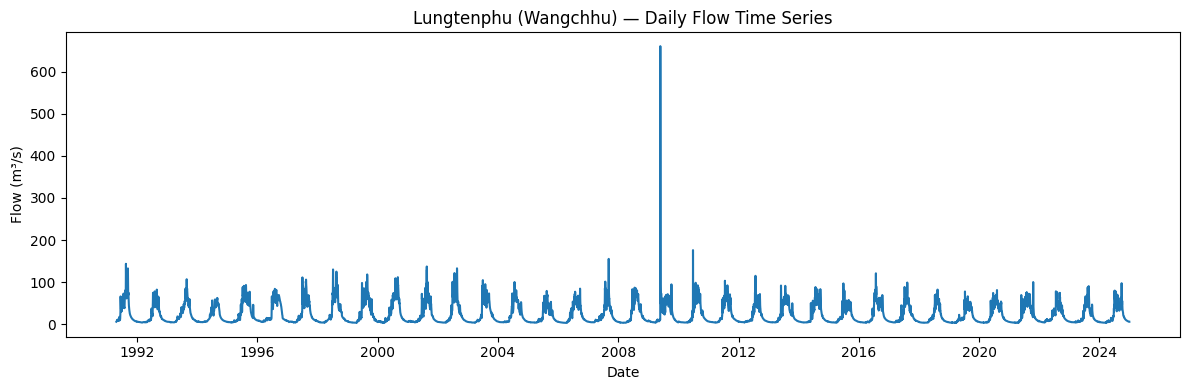

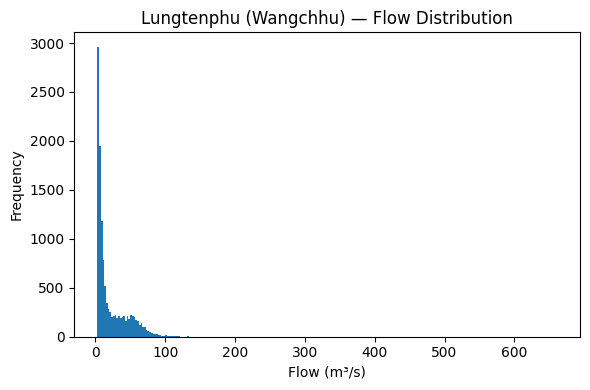

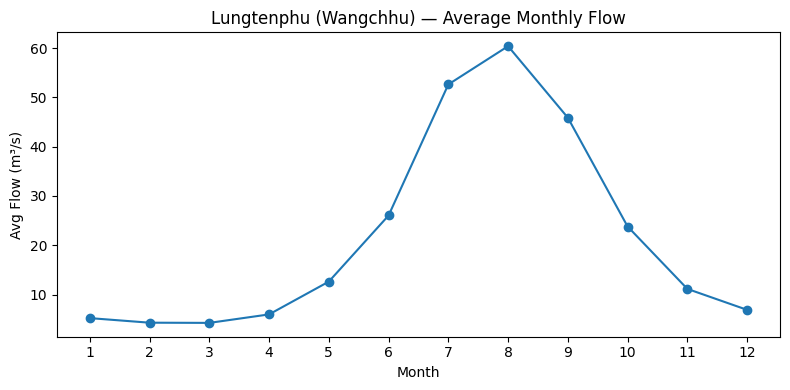

,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,Wangdi rapid (Punatshangchhu),2000-01-01,2023-12-31,8766,298.200705,162.571,51.713,2650.26,279.563571,42,1,0.967266


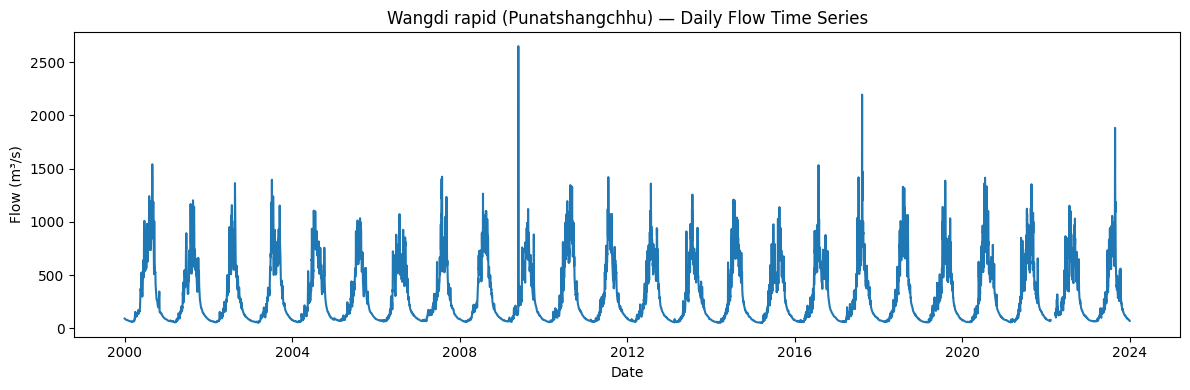

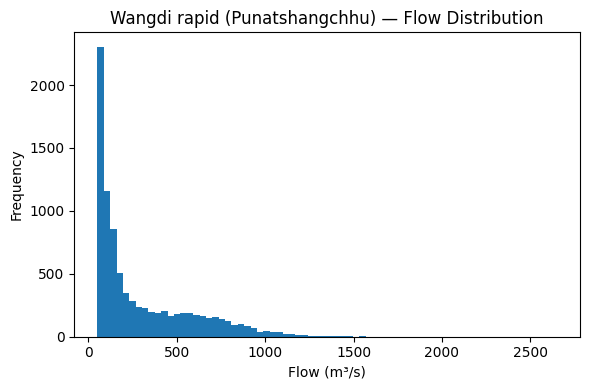

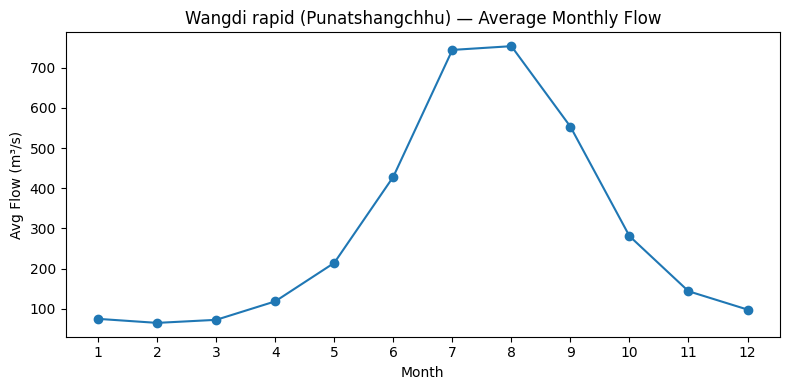

,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,Pangbang dangmechhu,2011-01-01,2023-12-31,4748,781.430324,416.2985,119.147,7131.638,822.571684,0,0,0.952314


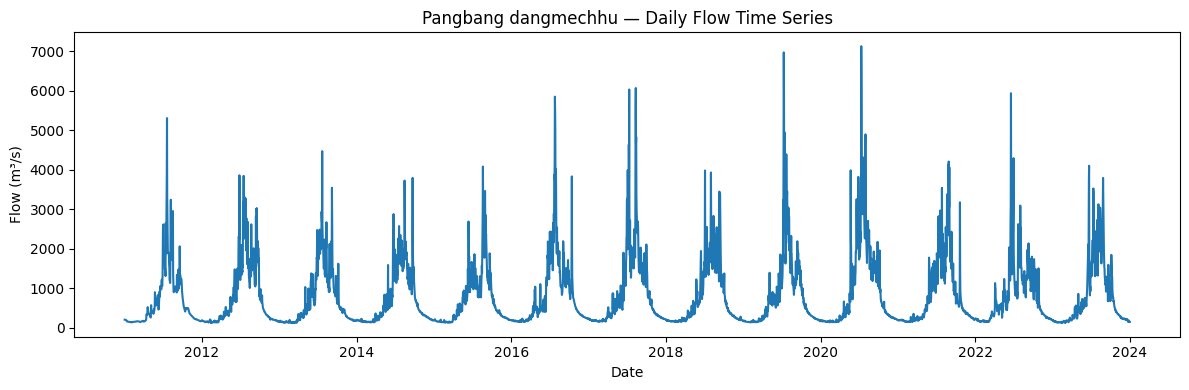

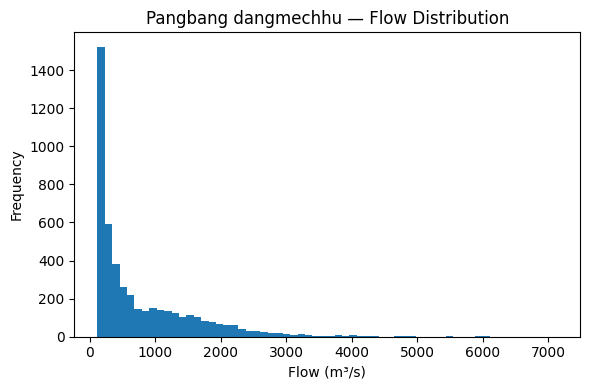

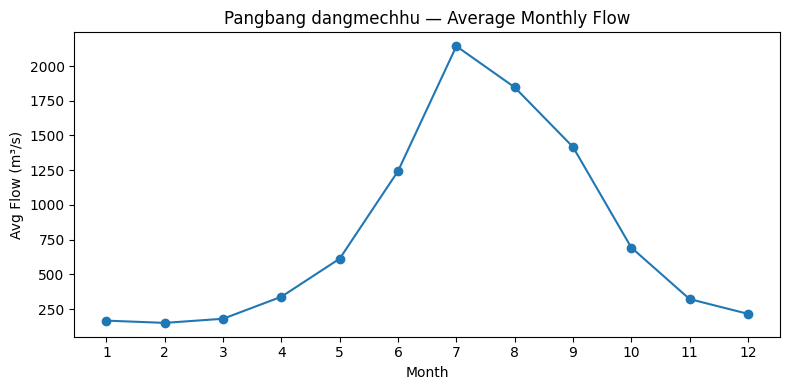

,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,tingtibi (Mangdichhu),2005-06-26,2023-12-31,6763,136.893623,79.508,23.45,2173.866,124.542809,6,371,0.843014


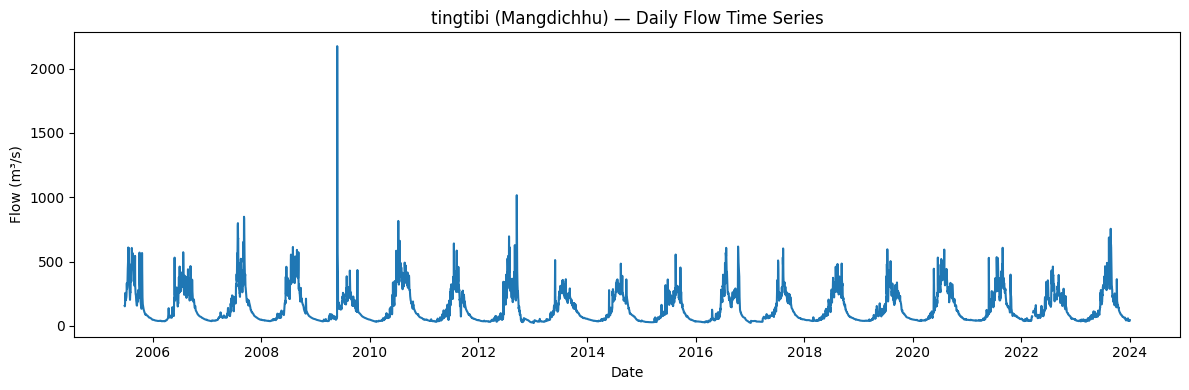

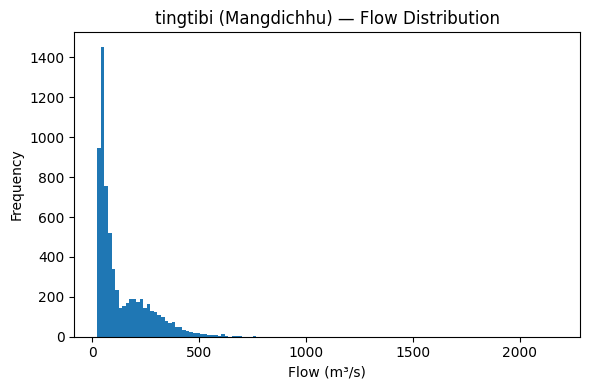

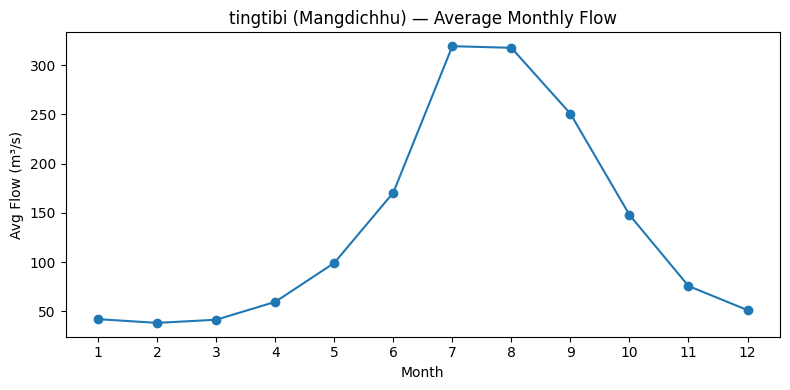

,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,Kurjey (Chamkharchhu),2000-01-01,2023-12-31,8766,52.351836,30.61,9.431,586.056,48.062139,0,9,0.856908


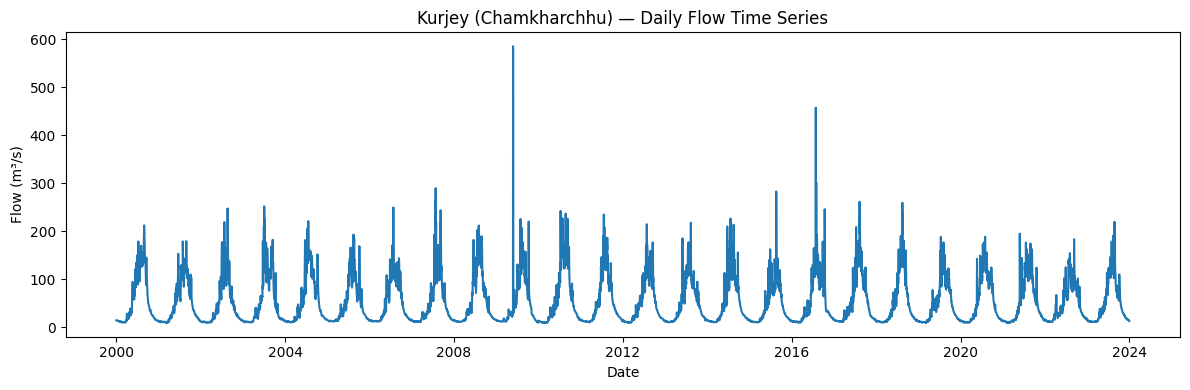

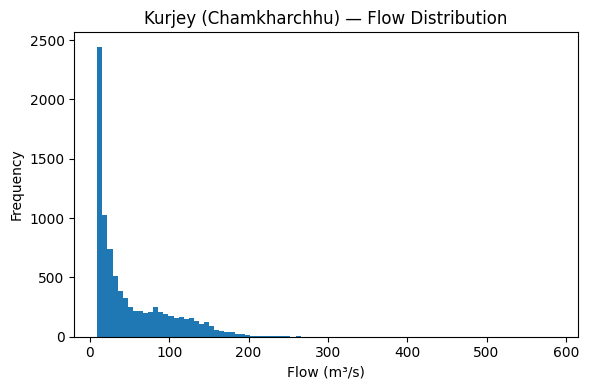

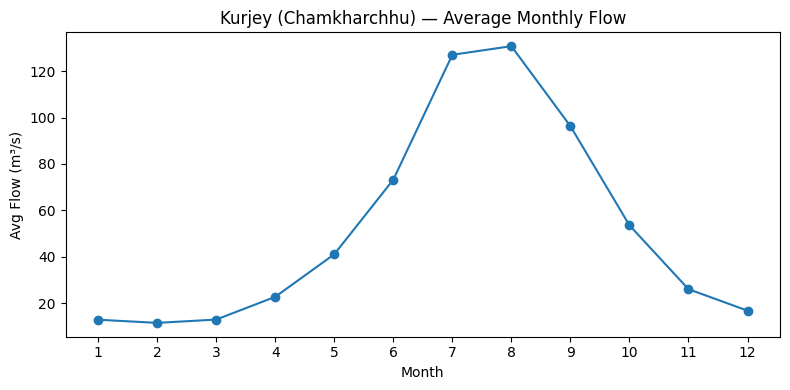

In [7]:
all_summaries = []
monthly_tables = {}

for sheet in sheets:
    station = sheet
    try:
        df = load_station_sheet(INPUT_XLSX, sheet_name=sheet, skiprows=SKIPROWS)
    except Exception as e:
        print(f"[WARN] Skipping '{sheet}': {e}")
        continue

    # Summary table row
    summ = station_summary(df)
    row = {"Station": station, **summ}
    all_summaries.append(row)

    # Inline visuals
    display(pd.DataFrame([row]))
    show_timeseries(df, station)
    show_histogram(df, station)
    monthly_tables[station] = compute_monthly_means(df, station)


## 8) Combined monthly average flow across stations (inline)

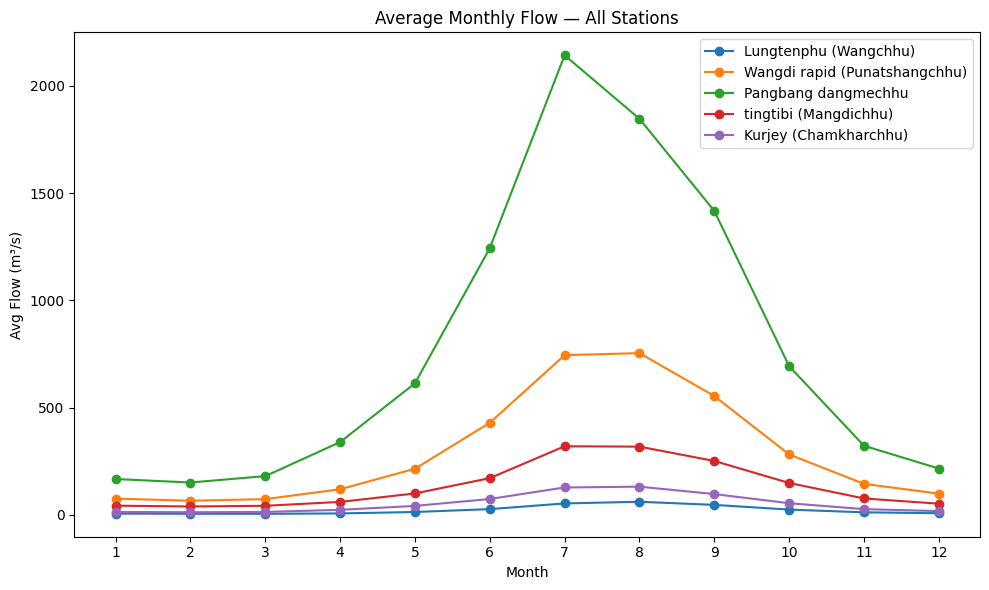

In [8]:
plt.figure(figsize=(10, 6))
for station, mdf in monthly_tables.items():
    if mdf is None or mdf.empty:
        continue
    plt.plot(mdf["Month"], mdf["Flow"], marker="o", label=station)
plt.xlabel("Month"); plt.ylabel("Avg Flow (m³/s)")
plt.title("Average Monthly Flow — All Stations")
plt.xticks(range(1, 13))
plt.legend(); plt.tight_layout(); plt.show()
